In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE


print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
# Load Final Dataset

output_path = "C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Outputs/"

X_train = pd.read_csv(output_path + "X_train_final.csv")
X_test = pd.read_csv(output_path + "X_test_final.csv")

y_train = pd.read_csv(
    output_path + "y_train_final.csv"
).squeeze("columns")

y_test = pd.read_csv(
    output_path + "y_test_final.csv"
).squeeze("columns")

print("Datasets Loaded Successfully")

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)




Datasets Loaded Successfully

Training Shape : (12365, 44)
Testing Shape  : (3092, 44)


In [3]:
# Verify Dataset

print("="*60)
print("FINAL DATASET SUMMARY")
print("="*60)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("Features :", X_train.shape[1])

print("\nMissing Values")

print("Training :", X_train.isna().sum().sum())
print("Testing  :", X_test.isna().sum().sum())

print("\nTarget Distribution")

print("\nTraining")

print(round(y_train.value_counts(normalize=True)*100,2))

print("\nTesting")

print(round(y_test.value_counts(normalize=True)*100,2))



FINAL DATASET SUMMARY
Training Samples : 12365
Testing Samples  : 3092
Features : 44

Missing Values
Training : 0
Testing  : 0

Target Distribution

Training
Composite_CVD
0    92.71
1     7.29
Name: proportion, dtype: float64

Testing
Composite_CVD
0    92.72
1     7.28
Name: proportion, dtype: float64


In [4]:
# ==========================================================
# Handle Class Imbalance Using SMOTE
# ==========================================================

smote = SMOTE(
    random_state=42
)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

print("="*60)
print("AFTER SMOTE")
print("="*60)

print("Training Shape :", X_train_balanced.shape)

print("\nTarget Distribution")

print(y_train_balanced.value_counts())


AFTER SMOTE
Training Shape : (22928, 44)

Target Distribution
Composite_CVD
0    11464
1    11464
Name: count, dtype: int64


In [5]:
# ==========================================================
# Build XGBoost Model
# ==========================================================

xgb_model = XGBClassifier(

    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

print("XGBoost Model Created Successfully")

XGBoost Model Created Successfully


In [6]:
xgb_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("XGBoost Training Completed")

XGBoost Training Completed


In [7]:
# ==========================================================
# Predictions
# ==========================================================

y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Predictions Completed")

Predictions Completed


In [8]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)
xgb_mcc = matthews_corrcoef(y_test, y_pred_xgb)
xgb_kappa = cohen_kappa_score(y_test, y_pred_xgb)

print("="*60)
print("XGBOOST PERFORMANCE")
print("="*60)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC AUC  : {xgb_auc:.4f}")
print(f"MCC      : {xgb_mcc:.4f}")
print(f"Kappa    : {xgb_kappa:.4f}")

XGBOOST PERFORMANCE
Accuracy : 0.9091
Precision: 0.3627
Recall   : 0.3289
F1 Score : 0.3450
ROC AUC  : 0.9007
MCC      : 0.2967
Kappa    : 0.2963


In [9]:
# ==========================================================
# Classification Report
# ==========================================================

print(classification_report(
    y_test,
    y_pred_xgb
))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      2867
           1       0.36      0.33      0.34       225

    accuracy                           0.91      3092
   macro avg       0.66      0.64      0.65      3092
weighted avg       0.91      0.91      0.91      3092



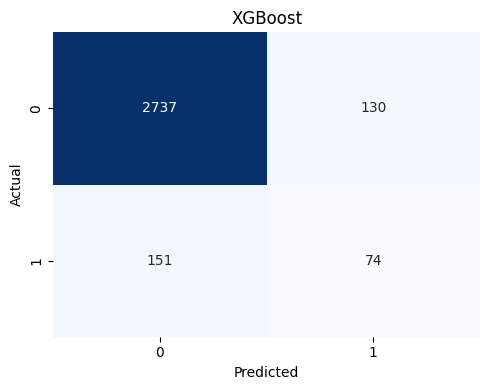

In [10]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("XGBoost")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

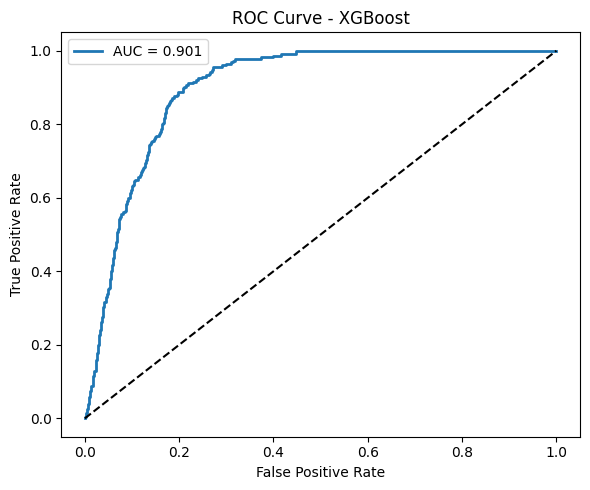

In [11]:
# ==========================================================
# ROC Curve
# ==========================================================

fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {xgb_auc:.3f}"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend()

plt.tight_layout()
plt.show()

In [12]:
# ==========================================================
# Feature Importance
# ==========================================================

xgb_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": xgb_model.feature_importances_

})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

display(xgb_importance.head(20))

,Feature,Importance
3,BPQ090D,0.448162
2,BPQ020,0.277208
5,MCQ160A,0.060803
32,SMQ020,0.030530
7,RIDAGEYR,0.015230
28,LBXPFNA,0.013448
35,URXUCD,0.008926
34,URXUCO,0.006993
13,URXUPB,0.006430
14,URXUTL,0.006143


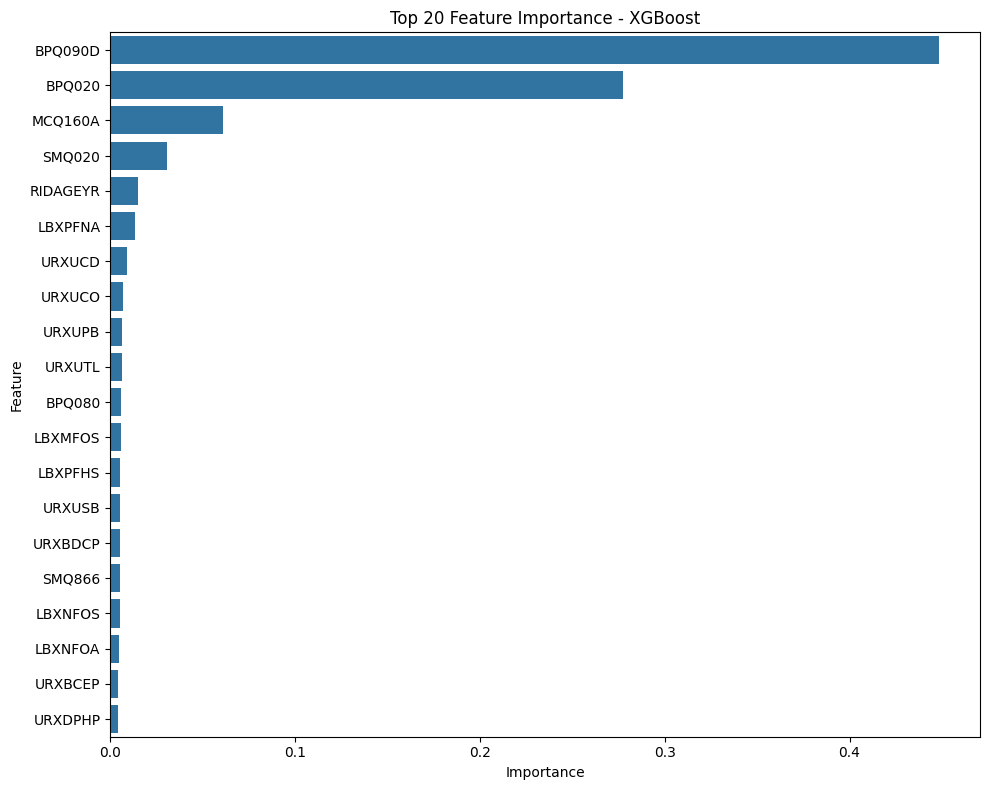

In [13]:
# ==========================================================
# Top 20 Feature Importance
# ==========================================================

plt.figure(figsize=(10,8))

sns.barplot(
    data=xgb_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importance - XGBoost")

plt.tight_layout()

plt.show()

In [14]:
model_path = "C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Models/"

os.makedirs(model_path, exist_ok=True)

joblib.dump(
    xgb_model,
    model_path + "XGBoost_Model.pkl"
)

['C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Models/XGBoost_Model.pkl']

In [15]:
# ==========================================================
# Save Feature Importance
# ==========================================================

xgb_importance.to_csv(
    output_path + "XGBoost_Feature_Importance.csv",
    index=False
)

print("XGBoost Feature Importance Saved Successfully")

XGBoost Feature Importance Saved Successfully
